# ResNet-18 PCA variance and visual extrema

This notebook analyzes the **raw, non-inverted** frozen ResNet-18 embeddings. No global spin symmetry is imposed before the network.

It answers four questions:

1. How is explained variance distributed across principal components?
2. How many PCs are needed to capture 90% of the embedding variance?
3. What do the actual configurations at the negative and positive extrema of PCs 1–5 look like?


In [1]:
from pathlib import Path
import json
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

L = 16
N_SITES = L ** 2
N_RUNS = 1_000
N_TEMPERATURES = 31
BINS_PER_TEMPERATURE = 10
N_CONFIGURATIONS = N_RUNS * N_TEMPERATURES * BINS_PER_TEMPERATURE

candidate_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parents[1]]
REPO_ROOT = next(root for root in candidate_roots if (root / "data" / "raw").exists())
DATA_ROOT = REPO_ROOT / "data" / "raw"
OUTPUT_ROOT = REPO_ROOT / "data" / "processed"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

EMBEDDING_PATH = OUTPUT_ROOT / "ising16_resnet18_raw_embeddings.npy"
TEMPERATURE_PATH = OUTPUT_ROOT / "ising16_resnet18_raw_temperatures.npy"
MAGNETIZATION_PATH = OUTPUT_ROOT / "ising16_resnet18_raw_signed_magnetization.npy"

assert EMBEDDING_PATH.exists(), "Run ising16_magnetization.ipynb first to create raw ResNet embeddings."
embeddings = np.load(EMBEDDING_PATH, mmap_mode="r")
embedding_temperatures = np.load(TEMPERATURE_PATH)
assert embeddings.shape == (N_CONFIGURATIONS, 512)

run_dirs = sorted(
    DATA_ROOT.glob("ising16_tc_[0-9]*"),
    key=lambda path: int(path.name.rsplit("_", 1)[1]),
)
assert len(run_dirs) == N_RUNS

temperature_grid = embedding_temperatures.reshape(
    N_RUNS, N_TEMPERATURES, BINS_PER_TEMPERATURE
)
temperatures = temperature_grid[0, :, 0]
assert np.all(temperature_grid == temperatures[None, :, None])

print(f"Embeddings: {embeddings.shape}")
print(f"Temperatures: {temperatures[0]:g} to {temperatures[-1]:g}")

Embeddings: (310000, 512)
Temperatures: 1.5 to 3


## Magnetization calculated directly from spins

Signed magnetization is recomputed as $m=\sum_i s_i/L^2$ and cached for later notebooks.

In [2]:
if MAGNETIZATION_PATH.exists():
    signed_magnetization = np.load(MAGNETIZATION_PATH)
else:
    signed_magnetization = np.empty(N_CONFIGURATIONS, dtype=np.float32)
    offset = 0
    for run_index, run_dir in enumerate(run_dirs):
        suffix = run_dir.name
        spins = np.loadtxt(
            run_dir / f"spinConfigs_{suffix}.txt", dtype=np.int8
        )
        count = len(spins)
        signed_magnetization[offset:offset + count] = (
            spins.sum(axis=1, dtype=np.int32) / N_SITES
        )
        offset += count
        if (run_index + 1) % 200 == 0:
            print(f"Read {run_index + 1:,}/{N_RUNS:,} runs")
    assert offset == N_CONFIGURATIONS
    np.save(MAGNETIZATION_PATH, signed_magnetization)

abs_magnetization = np.abs(signed_magnetization)
print(f"Magnetization cache: {signed_magnetization.shape}")

Magnetization cache: (310000,)


## Exact covariance eigendecomposition

The 512×512 covariance is accumulated in GPU-friendly batches and diagonalized exactly. This avoids guessing a component cutoff with a truncated PCA solver.

In [3]:
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
COVARIANCE_PATH = OUTPUT_ROOT / "ising16_resnet18_raw_covariance.npz"

if COVARIANCE_PATH.exists():
    covariance_cache = np.load(COVARIANCE_PATH)
    feature_mean = covariance_cache["feature_mean"]
    eigenvalues = covariance_cache["eigenvalues"]
    components = covariance_cache["components"]
else:
    feature_sum = torch.zeros(512, dtype=torch.float64, device=DEVICE)
    second_moment = torch.zeros((512, 512), dtype=torch.float64, device=DEVICE)
    batch_size = 8_192

    for start in range(0, N_CONFIGURATIONS, batch_size):
        stop = min(start + batch_size, N_CONFIGURATIONS)
        batch = torch.from_numpy(np.asarray(embeddings[start:stop])).to(
            DEVICE, dtype=torch.float64
        )
        feature_sum += batch.sum(dim=0)
        second_moment += batch.T @ batch

    feature_mean_tensor = feature_sum / N_CONFIGURATIONS
    covariance = (
        second_moment - N_CONFIGURATIONS * torch.outer(feature_mean_tensor, feature_mean_tensor)
    ) / (N_CONFIGURATIONS - 1)
    eigenvalues_tensor, eigenvectors_tensor = torch.linalg.eigh(covariance)
    order = torch.argsort(eigenvalues_tensor, descending=True)

    eigenvalues = eigenvalues_tensor[order].cpu().numpy()
    components = eigenvectors_tensor[:, order].T.cpu().numpy()
    feature_mean = feature_mean_tensor.cpu().numpy()
    np.savez(
        COVARIANCE_PATH,
        feature_mean=feature_mean,
        eigenvalues=eigenvalues,
        components=components,
    )

explained_variance_ratio = eigenvalues / eigenvalues.sum()
cumulative_variance = np.cumsum(explained_variance_ratio)
n_components_90 = int(np.searchsorted(cumulative_variance, 0.90) + 1)

print(f"Device: {DEVICE}")
print(f"PCs required for 90% variance: {n_components_90}")
print(f"Variance retained: {cumulative_variance[n_components_90 - 1]:.3%}")

Device: cuda
PCs required for 90% variance: 22
Variance retained: 90.055%


## Explained-variance bar chart

Bars show the individual explained-variance ratio for every PC retained by the 90% cutoff. The cumulative curve is included on a second axis to make the cutoff explicit.

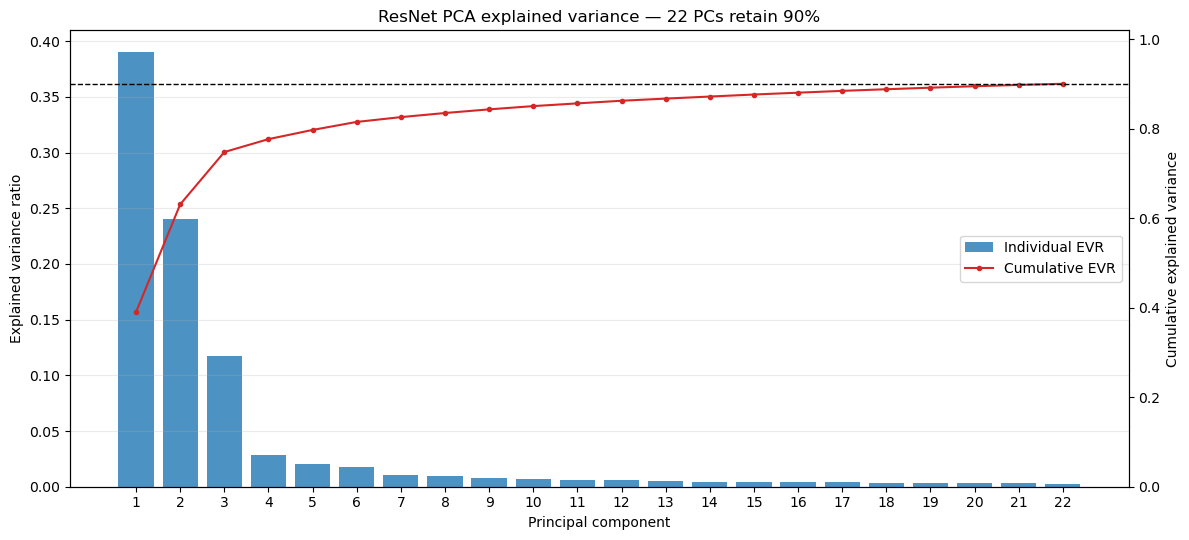

In [4]:
retained_pc_numbers = np.arange(1, n_components_90 + 1)

fig, ax = plt.subplots(figsize=(12, 5.5))
bars = ax.bar(
    retained_pc_numbers,
    explained_variance_ratio[:n_components_90],
    color="tab:blue",
    alpha=0.8,
    label="Individual EVR",
)
ax.set(
    xlabel="Principal component",
    ylabel="Explained variance ratio",
    title=f"ResNet PCA explained variance — {n_components_90} PCs retain 90%",
    xticks=retained_pc_numbers,
)
ax.grid(axis="y", alpha=0.25)

cumulative_axis = ax.twinx()
cumulative_axis.plot(
    retained_pc_numbers,
    cumulative_variance[:n_components_90],
    color="tab:red",
    marker="o",
    markersize=3,
    label="Cumulative EVR",
)
cumulative_axis.axhline(0.90, color="black", linestyle="--", linewidth=1)
cumulative_axis.set_ylabel("Cumulative explained variance")
cumulative_axis.set_ylim(0, 1.02)

handles_1, labels_1 = ax.get_legend_handles_labels()
handles_2, labels_2 = cumulative_axis.get_legend_handles_labels()
ax.legend(handles_1 + handles_2, labels_1 + labels_2, loc="center right")
fig.tight_layout()
fig.savefig(OUTPUT_ROOT / "ising16_resnet18_raw_pca_variance_bars.png", dpi=250, bbox_inches="tight")
plt.show()
plt.close(fig)

In [5]:
SCORES_PATH = OUTPUT_ROOT / "ising16_resnet18_raw_pca90_scores.npy"
PCA_METADATA_PATH = OUTPUT_ROOT / "ising16_resnet18_raw_pca90_metadata.json"

if SCORES_PATH.exists():
    pca90_scores = np.load(SCORES_PATH, mmap_mode="r")
else:
    pca90_scores = np.lib.format.open_memmap(
        SCORES_PATH,
        mode="w+",
        dtype=np.float32,
        shape=(N_CONFIGURATIONS, n_components_90),
    )
    for start in range(0, N_CONFIGURATIONS, 8_192):
        stop = min(start + 8_192, N_CONFIGURATIONS)
        centered = np.asarray(embeddings[start:stop]) - feature_mean
        pca90_scores[start:stop] = centered @ components[:n_components_90].T
    pca90_scores.flush()

with open(PCA_METADATA_PATH, "w") as handle:
    json.dump(
        {
            "n_components_90": n_components_90,
            "variance_retained": float(cumulative_variance[n_components_90 - 1]),
            "n_configurations": N_CONFIGURATIONS,
            "embedding_dimension": 512,
            "spin_inversion_used": False,
        },
        handle,
        indent=2,
    )

## Visual extrema of PCs 1–5

For each component, the left panel is the **actual 16×16 configuration with the minimum score** and the right panel is the actual configuration with the maximum score. Nothing is averaged or reconstructed. Titles report temperature, signed magnetization, and PC score so the visual direction of each component can be interpreted directly.

The sign of a PCA component is mathematically arbitrary; “minimum” and “maximum” describe the fitted orientation, not an intrinsic physical sign.

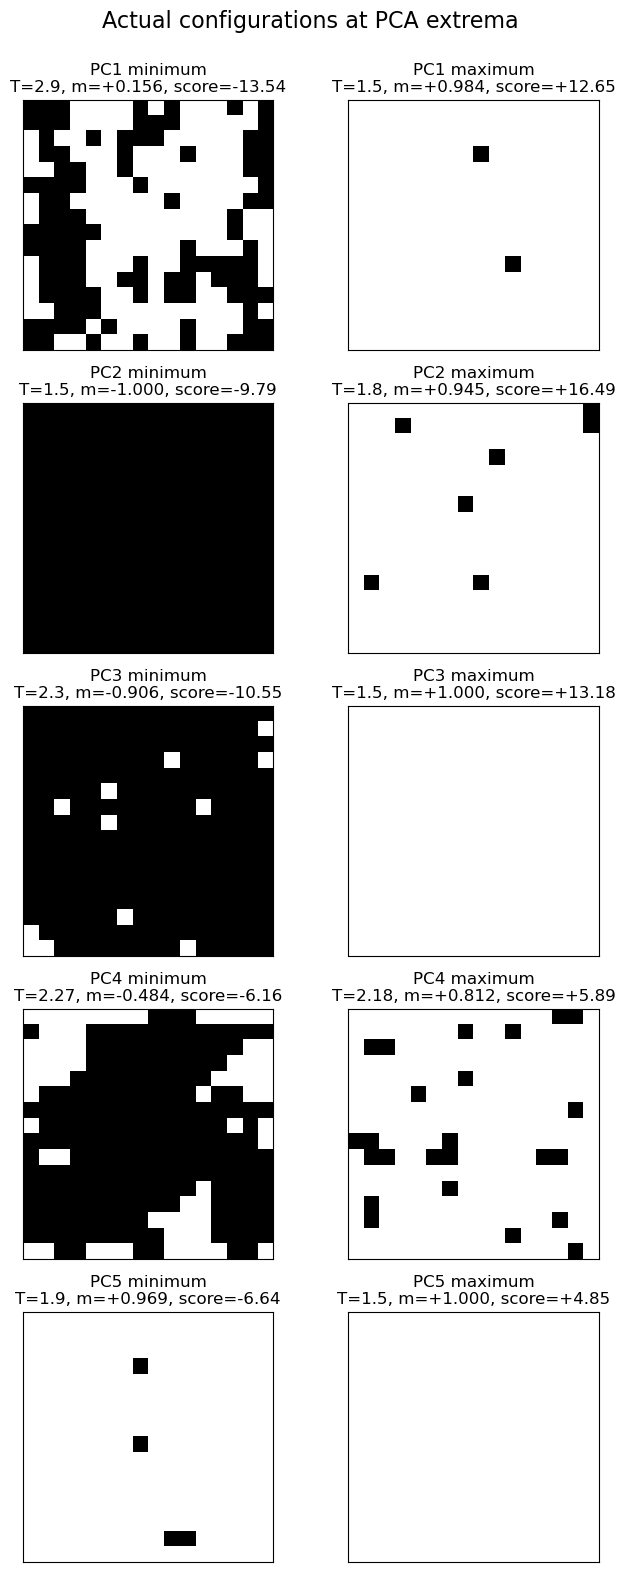

,principal_component,extremum,global_index,temperature,signed_magnetization,pc_score
0,1,minimum,30984,2.90,0.156250,-13.541574
1,1,maximum,61079,1.50,0.984375,12.650054
2,2,minimum,5,1.50,-1.000000,-9.793309
3,2,maximum,263842,1.80,0.945312,16.486181
4,3,minimum,257483,2.30,-0.906250,-10.546813
5,3,maximum,6,1.50,1.000000,13.184939
6,4,minimum,179336,2.27,-0.484375,-6.159313
7,4,maximum,109834,2.18,0.812500,5.889070
8,5,minimum,287728,1.90,0.968750,-6.643262
9,5,maximum,6,1.50,1.000000,4.846273


In [6]:
def load_spin_configuration(global_index):
    configurations_per_run = N_TEMPERATURES * BINS_PER_TEMPERATURE
    run_index, row_index = divmod(int(global_index), configurations_per_run)
    run_dir = run_dirs[run_index]
    suffix = run_dir.name
    configuration = np.loadtxt(
        run_dir / f"spinConfigs_{suffix}.txt",
        dtype=np.int8,
        skiprows=row_index,
        max_rows=1,
    )
    return configuration.reshape(L, L)

extrema_rows = []
fig, axes = plt.subplots(5, 2, figsize=(7, 16))

for pc_index in range(5):
    scores = np.asarray(pca90_scores[:, pc_index])
    minimum_index = int(np.argmin(scores))
    maximum_index = int(np.argmax(scores))

    for column, (label, sample_index) in enumerate((
        ("minimum", minimum_index),
        ("maximum", maximum_index),
    )):
        configuration = load_spin_configuration(sample_index)
        temperature = float(embedding_temperatures[sample_index])
        magnetization = float(signed_magnetization[sample_index])
        score = float(scores[sample_index])

        axes[pc_index, column].imshow(
            configuration,
            cmap="gray",
            vmin=-1,
            vmax=1,
            interpolation="nearest",
        )
        axes[pc_index, column].set_title(
            f"PC{pc_index + 1} {label}\n"
            f"T={temperature:g}, m={magnetization:+.3f}, score={score:+.2f}"
        )
        axes[pc_index, column].set_xticks([])
        axes[pc_index, column].set_yticks([])

        extrema_rows.append({
            "principal_component": pc_index + 1,
            "extremum": label,
            "global_index": sample_index,
            "temperature": temperature,
            "signed_magnetization": magnetization,
            "pc_score": score,
        })

fig.suptitle("Actual configurations at PCA extrema", fontsize=16)
fig.tight_layout(rect=(0, 0, 1, 0.98))
fig.savefig(OUTPUT_ROOT / "ising16_resnet18_raw_pc1-5_extrema.png", dpi=250, bbox_inches="tight")
plt.show()
plt.close(fig)

extrema_table = pd.DataFrame(extrema_rows)
extrema_table.to_csv(OUTPUT_ROOT / "ising16_resnet18_raw_pc1-5_extrema.csv", index=False)
extrema_table